# MachineLearning is all about
1. Getting data converted to numerical representation.
2. Building a model to learn pattern from numerical data made in step 1.

In [1]:
import torch

## step1: Create/load sample dataset

In [2]:
# y=mx+c
# y=dependent variable, x=independent variable, m=weight, c=bias

# assumed variables
weight = 0.7 # m
bias = 0.3 # c

# let's create a dataset
X = torch.arange(0,1,0.02).unsqueeze(dim=1) # add extra dimension
y = weight*X + bias
X[:5], y[:5], X.shape, y.shape

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]),
 torch.Size([50, 1]),
 torch.Size([50, 1]))

## step2: creat train & test data set

In [3]:
splitter = int(0.8*len(X))
splitter

40

In [4]:
x_train, y_train = X[:splitter], y[:splitter]
x_test, y_test = X[splitter:], y[splitter:]
x_train.shape

torch.Size([40, 1])

## step3: visualize data

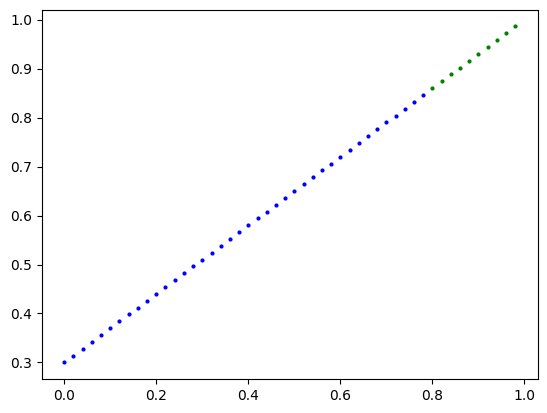

In [5]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, c='b', s=4)
plt.scatter(x_test, y_test, c='g', s=4)

## step4: build model

In [6]:
import torch
from torch import nn

#### What our model does:
1. `Start with random values, i.e., weights and bias.`
2. `Look at training data and adjust the random values to become a better representation of data.`

#### How it do so:
1. `Gradient descent.`
2. `Back Propagation.`

In [7]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.weights * x + self.bias
        

## model building essentials
#### torch.nn (all building blocks here to make a graph)
#### torch.nn.parameters (what parameters should a model try and learn)
#### torch.nn.module (base class for all neural network models, including custom-made) | always overwrite the forward method
#### torch.optim (optimizers of PyTorch help in gradient descent)
#### def forward (defines what happens in forward computation)

## step5:check content of pytorch model

In [8]:
# create a random seed
ranadom_seed = 42
torch.manual_seed(ranadom_seed)

# create instance of class
model0 = LinearRegressionModel()
model0

LinearRegressionModel()

In [9]:
list(model0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
model0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# aim is to make these weights=0.3367 and biases =0.1288 from the model to move values towards our assumed initial values, i.e., weight = 0.7, bias = 0.3

In [11]:
# simple mode
y_preds_simple_mode = model0(x_test)
y_preds_simple_mode

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [12]:
# inference mode
with torch.inference_mode():
    y_preds = model0(x_test)
    

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

## Diff b/w Normal mode and Inference mode
|Normal mode|Inference mode|
|-----------|-------------|
|Pytorch learning from data, tracking gradients & building graphs.|Pytorch only doing inference, NOT tracking gradients & NOT build graphs.|
|Calls model0.forward(x_test)|Avoids storing intermediate tensors|
|Tracks the computation graph (by default)|Prevents version counter updates|
|Enables autograd so gradients can be computed later|Disables autograd|
|Autograd behavior: a: PyTorch records every operation, |Optimizes memory & speed|
|b : Builds a dynamic computation graph,||
|c : Stores intermediate tensors for backprop||
|loss is possible to calculate here |loss calculations is not possible here|
|uses/ Advantages| used/ Advantages|
|1.training|prediction|
|2. When you need .backward()||
|3. When computing gradients manually||
|Disdvantages|Disdvantages|
|1. Extra memory usage||
|2. Slower inference||
|3. Risk of accidentally calling .backward()||
|4. Dropout / BatchNorm may behave incorrectly if not in eval mode||



| Aspect            | Normal Call | `inference_mode()` |
| ----------------- | ----------- | ------------------ |
| Gradient tracking | ✅ Yes       | ❌ No               |
| Computation graph | Built       | Not built          |
| Memory usage      | Higher      | Lower              |
| Speed             | Slower      | Faster             |
| Backprop allowed  | ✅ Yes       | ❌ No               |
| Deployment safe   | ❌ Risky     | ✅ Ideal            |


# torch.eval is different from inference mode
# inference mode is stronger than torch.no_grad()

## model.eval()
What it does:
1. Changes layer behavior
2. Dropout → OFF
3. BatchNorm → uses running stats
   
What it does NOT do:
1. Does NOT disable gradients
2. Does NOT stop graph creation

| Feature         | no_grad    | inference_mode       |
| --------------- | ---------- | -------------------- |
| Disables grad   | ✅          | ✅                    |
| Graph building  | ❌          | ❌                    |
| Version counter | ✅          | ❌                    |
| Speed           | Good       | Best                 |
| Use case        | Validation | Deployment / Testing |

# Mental model (important)
## Training → “Learn & remember” → model(x)
## Evaluation → “Observe carefully” → eval() + inference_mode()
## Deployment → “Just predict fast” → eval() + inference_mode()

#### Example: Driving analogy 🚗

Evaluation:
Test drive the car on a track
→ Helmet on, safety mode ON

Deployment:
Taxi service running 24/7
→ Speed limits, fuel efficiency, zero crashes

Same seatbelt, but stakes are different.

## plotting predictions

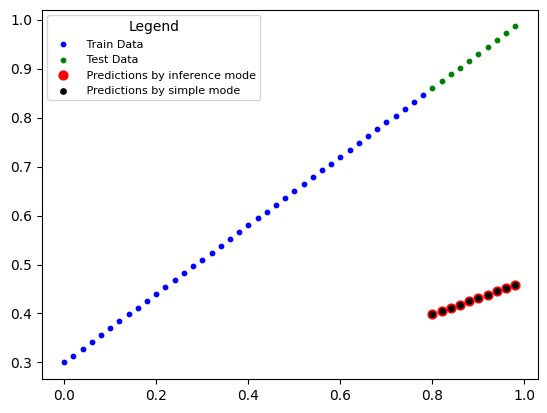

In [13]:
plt.scatter(x_train,y_train, c='b', s=10, label=' Train Data')
plt.scatter(x_test,y_test, c='g', s=10, label=' Test Data')
plt.scatter(x_test,y_preds, c='r', s=40, label=' Predictions by inference mode')
plt.scatter(x_test.numpy(),y_preds_simple_mode.detach(), c='black', s=15, label=' Predictions by simple mode')
plt.legend(   frameon=True, title="Legend", fontsize=8,)

# Actual Training (From unknown random params to known params)

`REQUIREMENTS:`
* Loss function
* Optimizer
* TRAINING LOOP
* TESTING LOOP

`EXPLANATION`
1. Need a LOSS FUNCTION / LOSS FUNCTION/ CRITERION (all are the same)to measure how poorly our model is performing OR loss function measures how wrong our model's parameters are (weights, bias)
2. Need an OPTIMIZER, which takes into account the loss in each iteration / Epoch and adjusts the parameters.


#### step0: List no fo parameters to be trained

In [14]:
list(model0.parameters()), model0.state_dict()

([Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)],
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))

#### step1: choose the loss function and the optimizer.

In [15]:
# loss function choosing
loss_fn = nn.L1Loss()

# optimizer function choosing
optimizer_fn = torch.optim.SGD(params=model0.parameters(), lr=0.01, )

# Easter egg 
#### e.g., our parameter is [weights = 0.3367] having 4 digits after decimal
#### if lr=0.0001, the optimizer starts changing the last digit, i.e., 7 of the weight(parameter), which means the change is quite small
#### if lr=0.001, optimizer starts changing the last second digit, i.e., 6 of the weight(parameter), which means the change is quite small, but greater than lr=0.0001
#### If I want to change the digit next to the decimal, i.e., 3, I must choose lr=0.1

#### Q: Which loss function and optimizer should I use?
#### A: Have patience, practicing different datasets and the nature of data will teach what to use when
####  e.g. 1. In a regression problem, we can use loss_fn=Li loss function(MAE) and optimizer=SGD
####       2. For a classification problem, we can use the BinaryCrossEntropy loss function       

#### step2: make the training loop 
* loop through the data.
* Forward pass (it involves data moving through the model's forward() function/functions). | make predictions on data | forward propagation
* Calculate the loss (compare forward pass predictions to ground truth labels)
* Optimize Zero Grad (will discuss later)
* **Back propagation:** Loss Backward | move backward through the network to calculate the gradient of each of the parameters of our model W.R.T the loss
* **gradient descent:** Adjust our model's parameters to minimize the loss | (optimizers). | chnage in slope and intercept in our case.

#### step3: set epoches

In [42]:
# set no of loops | a Hyperparameter
epoches = 100

In [43]:
# training loop
for epoch in range(epoches):
    # 0. TRAINING | PUT MODEL IN TRAINING MODE
    model0.train() 
    
    # 1. Setup forward pass | FORWARD PASS TRAINING DATA USING FORWARD() METHOD INSIDE MODEL OBJECT
    y_pred_learned = model0(x_train)
    
    # 2. Calculate the loss values | only calculations, nothing more | TRAINING LOSS
    loss = loss_fn(y_pred_learned, y_train) # input first target next
    print(loss)
    
    # 3. Optimizer zero grad | Prevents Gradient Accumulation after each loop & Memory Management
    optimizer_fn.zero_grad()
    
    # 4. Perform back propagation w.r.t paramaeters of the model
    loss.backward() # compute gradient of every parameter with require_grad = true | check minima(convergence point) is achieved or not
    
    # 5. Setup Optimizer | make a calculation of how to change the parameters w.r.t back propagation of loss
    optimizer_fn.step() # by default, how the optimizer changes(values) will accumulate through the loop, so we have to zero them above via step 3.

    # TESTING/Evaluation | loop can be put under running conditions like run after every 10 epoch. 
    # model0.eval()  # turn off different settings not needed in testing  mode, like gradient tracking, dropout, and batch normalization
    # with torch.inference_mode():
    #     y_preds_100 = model0(x_test)
    #     loss can be calculated here | and that will be called TESTING LOSS
    # print statements to be printed after each epoch

    print(f"\n actual weight and bias must be: {weight,bias} \n randomly initialized weight and bias are: 0.3367,0.1288 \n weights and biases after {epoches} are {model0.state_dict()}")

tensor(0.0372, grad_fn=<MeanBackward0>)

 actual weight and bias must be: (0.7, 0.3) 
 randomly initialized weight and bias are: 0.3367,0.1288 
 weights and biases after 100 are OrderedDict([('weights', tensor([0.5168])), ('bias', tensor([0.3768]))])
tensor(0.0368, grad_fn=<MeanBackward0>)

 actual weight and bias must be: (0.7, 0.3) 
 randomly initialized weight and bias are: 0.3367,0.1288 
 weights and biases after 100 are OrderedDict([('weights', tensor([0.5186])), ('bias', tensor([0.3763]))])
tensor(0.0365, grad_fn=<MeanBackward0>)

 actual weight and bias must be: (0.7, 0.3) 
 randomly initialized weight and bias are: 0.3367,0.1288 
 weights and biases after 100 are OrderedDict([('weights', tensor([0.5202])), ('bias', tensor([0.3753]))])
tensor(0.0361, grad_fn=<MeanBackward0>)

 actual weight and bias must be: (0.7, 0.3) 
 randomly initialized weight and bias are: 0.3367,0.1288 
 weights and biases after 100 are OrderedDict([('weights', tensor([0.5220])), ('bias', tensor([0.3748])

In [30]:
# before moving to accuracy lets see if there is any effect on predicted values
# Let's predict with this half-trained model
with torch.inference_mode():
    y_preds_new = model0(x_test)

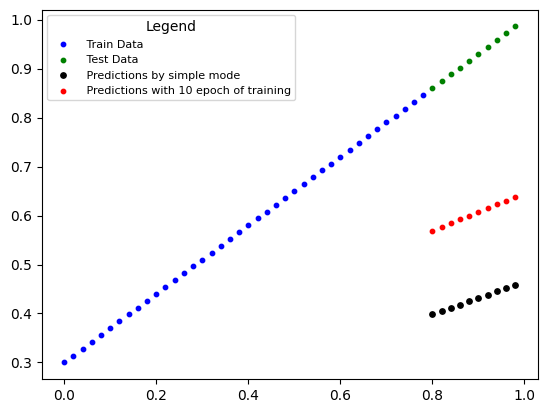

In [31]:
plt.scatter(x_train,y_train, c='b', s=10, label=' Train Data')
plt.scatter(x_test,y_test, c='g', s=10, label=' Test Data')
plt.scatter(x_test.numpy(),y_preds_simple_mode.detach(), c='black', s=15, label=' Predictions by simple mode')
plt.scatter(x_test,y_preds_new, c='r', s=10, label=' Predictions with 10 epoch of training')
plt.legend(   frameon=True, title="Legend", fontsize=8,)

In [35]:
# with 50 epochs
with torch.inference_mode():
    y_preds_new_100 = model0(x_test) # by mistake put 100 here, I tried with 50 epochs only.

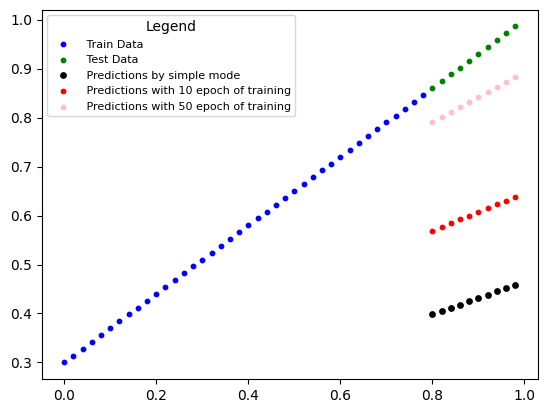

In [41]:
plt.scatter(x_train,y_train, c='b', s=10, label=' Train Data')
plt.scatter(x_test,y_test, c='g', s=10, label=' Test Data')
plt.scatter(x_test.numpy(),y_preds_simple_mode.detach(), c='black', s=15, label=' Predictions by simple mode')
plt.scatter(x_test,y_preds_new, c='r', s=10, label=' Predictions with 10 epoch of training')
plt.scatter(x_test,y_preds_new_100, c='pink', s=10, label=' Predictions with 50 epoch of training')
plt.legend(   frameon=True, title="Legend", fontsize=8,)

In [44]:
# with 50 epochs
with torch.inference_mode():
    y_preds_new_100_actual = model0(x_test)

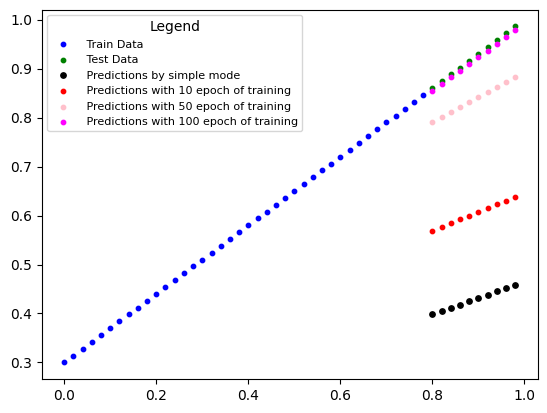

In [46]:
plt.scatter(x_train,y_train, c='b', s=10, label=' Train Data')
plt.scatter(x_test,y_test, c='g', s=10, label=' Test Data')
plt.scatter(x_test.numpy(),y_preds_simple_mode.detach(), c='black', s=15, label=' Predictions by simple mode')
plt.scatter(x_test,y_preds_new, c='r', s=10, label=' Predictions with 10 epoch of training')
plt.scatter(x_test,y_preds_new_100, c='pink', s=10, label=' Predictions with 50 epoch of training')
plt.scatter(x_test,y_preds_new_100_actual, c='magenta', s=10, label=' Predictions with 100 epoch of training')
plt.legend(   frameon=True, title="Legend", fontsize=8,)

# To fully monitor the inside of training loop make following tweaks

In [ ]:
epoch = []
training_loss = []
testing_loss = []

# training loop
for epoch in range(epoches):
    # 0. TRAINING | PUT MODEL IN TRAINING MODE
    model0.train() 
    
    # 1. Setup forward pass | FORWARD PASS TRAINING DATA USING FORWARD() METHOD INSIDE MODEL OBJECT
    y_pred_learned = model0(x_train)
    
    # 2. Calculate the loss values | only calculations, nothing more | TRAINING LOSS
    loss = loss_fn(y_pred_learned, y_train) # input first target next
    print(loss)
    training_loss.append(loss)
    
    # 3. Optimizer zero grad | Prevents Gradient Accumulation after each loop & Memory Management
    optimizer_fn.zero_grad()
    
    # 4. Perform back propagation w.r.t paramaeters of the model
    loss.backward() # compute gradient of every parameter with require_grad = true | check minima(convergence point) is achieved or not
    
    # 5. Setup Optimizer | make a calculation of how to change the parameters w.r.t back propagation of loss
    optimizer_fn.step() # by default, how the optimizer changes(values) will accumulate through the loop, so we have to zero them above via step 3.

    # TESTING/Evaluation | loop can be put under running conditions like run after every 10 epoch. 
    # model0.eval()  # turn off different settings not needed in testing  mode, like gradient tracking, dropout, and batch normalization
    # with torch.inference_mode():
    #     y_preds_100 = model0(x_test)
    #     loss can be calculated here | and that will be called TESTING LOSS
    # print statements to be printed after each epoch
    # testing_loss.append(loss)

    print(f"\n actual weight and bias must be: {weight,bias} \n randomly initialized weight and bias are: 0.3367,0.1288 \n weights and biases after {epoches} are {model0.state_dict()}")
    

# now make graph from above mentioned lists to check what happened in which iteration

In [ ]:
# make graph of train loss and test loss using plt.plot